# Integrate growth data into the recoding AnnData

Takes the `recoding_landscape.h5ad` that `AGGREGATE_ANNDATA` publishes under
`${alignment.outdir}/recoding/anndata/` and joins the AMiGA growth summaries
onto `obs`, one growth row per clone.

Pipeline of this notebook:

1. **Config** — paths, how to read the sample/clone numbers out of `BAM_name`,
   and the clone → growth-plate rules (the only parts that change per run).
2. **Parse** the numbers, with a preview to check the regexes against real names.
3. **Assign** each clone its growth plate.
4. **Join** the AMiGA summaries onto `obs`, index-aligned (never a bare
   `obs.merge`, which reorders/drops rows and silently desynchronises `obs` from `X`).
5. **Derive** per-clone recoding metrics (`recoded_binary` layer, `recoded_total`,
   `recoded_fraction`, `mean_depth`) and filter.
6. **Summarise** growth per codon into `var`.
7. **Plots**, the two `recA_data.ipynb` landscape figures, and write
   `recoding_growth.h5ad`.

In [133]:
import os
import re
import warnings

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ad.settings.allow_write_nullable_strings = True
sns.set_theme(style='whitegrid')

## 1. Config

`RESULTS_DIR` is the pipeline's `alignment.outdir`. Everything else hangs off it.

**Name parsing.** Two numbers are pulled out of `BAM_name`: the *sample* number
(Illumina's trailing `_S<n>`) and the *clone* number (whatever the plate layout
numbered the well by). Which token is which differs per run, so both are plain
regexes with one capture group — swap or rewrite them to match your names:

| BAM_name | clone | sample |
|---|---|---|
| `Syn57evo2_Map_plate1_10_S10` | `10` (before `_S`) | `10` |
| `B10_map_DR_c100_S4` | `100` (after `_c`) | `4` |

**Plate rules.** Each rule maps clones onto one growth plate, matching on
`sample_nr`, `clone_nr` (inclusive ranges, `None` = don't constrain) and
optionally `bam_regex` against the whole `BAM_name` — the easy route when the
plate is written into the name (`..._plate1_...`). Rules are tried in order,
first match wins.

In [134]:
RESULTS_DIR  = '/Users/cristian.soitu/Data/260901_VH02427_87_AAJCWWFM5/results'
ANNDATA_DIR  = os.path.join(RESULTS_DIR, 'recoding', 'anndata')
AMIGA_DIR    = os.path.join(RESULTS_DIR, 'growth_data', 'amiga', 'summary')

IN_H5AD  = os.path.join(ANNDATA_DIR, 'recoding_landscape.h5ad')
OUT_H5AD = os.path.join(ANNDATA_DIR, 'recoding_growth.h5ad')

# How the two numbers are read out of BAM_name. One capture group each; set either
# to None to skip it (the field becomes NaN, and rules keyed on it stop matching).
# Swap the two lines to swap which number counts as what.
CLONE_REGEX  = r'_(\d+)_[Ss]\d+$'   # 'Syn57evo2_Map_plate1_10_S10' -> 10
# CLONE_REGEX = r'_c(\d+)'           # 'B10_map_DR_c100_S4'          -> 100
SAMPLE_REGEX = r'_[Ss](\d+)$'        # the trailing Illumina _S<n>

# Falls back to the number in obs['sample_ID'] wherever SAMPLE_REGEX finds nothing.
SAMPLE_NR_FROM_SAMPLE_ID = False

# AMiGA summary file name = '<growth_plate><AMIGA_SUFFIX>' in AMIGA_DIR.
AMIGA_SUFFIX = '_summary.txt'          # AMiGA's own default is '_summary.txt'

# growth_plate == the AMiGA Plate_ID. Ranges inclusive; None = unconstrained.
# Optional 'bam_regex' matches the whole BAM_name, e.g. r'_plate1_'.
PLATE_RULES = [
    {'growth_plate': 'Plate1',  'sample_nr': (1, 96),    'clone_nr': (1, 96)},
    {'growth_plate': 'Plate3',  'sample_nr': (97, 192),  'clone_nr': (1, 96)},
    {'growth_plate': 'Plate9',  'sample_nr': (193, 288), 'clone_nr': (1, 96)},
    {'growth_plate': 'Plate10', 'sample_nr': (289, 384), 'clone_nr': (1, 96)},
]

# Figures (section 10). FIG_DIR is created on demand.
FIG_DIR        = os.path.join(ANNDATA_DIR, 'figures')
HEATMAP_LABEL  = 'RecA'        # title over the clone x codon heatmap
LANDSCAPE_YLIM = (50, 200)     # y-limits of the landscape plot (doubling times)
TICKS_EVERY    = 1000          # heatmap x tick every N codons

# Filters / thresholds
MIXED_TRACE_THRESHOLD = 0.85   # call a codon recoded above this recoding fraction
DEPTH_THRESHOLD       = 1     # drop a clone below this mean depth
TD_THRESHOLD_MIN      = 300    # drop a clone slower than this doubling time (minutes)
OD_THRESHOLD          = None   # set a float to drop clones below this OD_Max

print('\n'.join(sorted(os.listdir(AMIGA_DIR))))

Plate1.txt
Plate10.txt
Plate10_diauxie.txt
Plate10_summary.txt
Plate1_diauxie.txt
Plate1_summary.txt
Plate3.txt
Plate3_diauxie.txt
Plate3_summary.txt
Plate9.txt
Plate9_diauxie.txt
Plate9_summary.txt


## 2. Load the recoding AnnData

In [135]:
adata = ad.read_h5ad(IN_H5AD)
print(adata)
adata.obs.head()

AnnData object with n_obs × n_vars = 384 × 101652
    obs: 'BAM_name', 'well_ID', 'well_nr', 'sample_ID', 'seq_plate_ID'
    var: 'position'
    layers: 'depth', 'recoded_count', None (.X)


,BAM_name,well_ID,well_nr,sample_ID,seq_plate_ID
Syn57evo2_Map_plate1_10_S10,Syn57evo2_Map_plate1_10_S10,B2,10,S10,1
Syn57evo2_Map_plate1_11_S11,Syn57evo2_Map_plate1_11_S11,C2,11,S11,1
Syn57evo2_Map_plate1_12_S12,Syn57evo2_Map_plate1_12_S12,D2,12,S12,1
Syn57evo2_Map_plate1_13_S13,Syn57evo2_Map_plate1_13_S13,E2,13,S13,1
Syn57evo2_Map_plate1_14_S14,Syn57evo2_Map_plate1_14_S14,F2,14,S14,1


In [136]:
adata.obs.tail(5)

,BAM_name,well_ID,well_nr,sample_ID,seq_plate_ID
Syn57evo2_plate10_93_S381,Syn57evo2_plate10_93_S381,E12,93,S381,4
Syn57evo2_plate10_94_S382,Syn57evo2_plate10_94_S382,F12,94,S382,4
Syn57evo2_plate10_95_S383,Syn57evo2_plate10_95_S383,G12,95,S383,4
Syn57evo2_plate10_96_S384,Syn57evo2_plate10_96_S384,H12,96,S384,4
Syn57evo2_plate10_9_S297,Syn57evo2_plate10_9_S297,A2,9,S297,4


## 3. Parse the sample and clone numbers

Run this, eyeball the preview, and adjust `CLONE_REGEX` / `SAMPLE_REGEX` in the
config until both columns hold what you expect — everything downstream keys off
them.

In [137]:
def parse_number(text, pattern):
    '''First capture group of `pattern` in `text` as an int; NaN if it misses.'''
    if pattern is None:
        return np.nan
    m = re.search(pattern, str(text), flags=re.IGNORECASE)
    return int(m.group(1)) if m else np.nan


bam = adata.obs['BAM_name']
adata.obs['clone_nr']  = [parse_number(b, CLONE_REGEX) for b in bam]
adata.obs['sample_nr'] = [parse_number(b, SAMPLE_REGEX) for b in bam]

if SAMPLE_NR_FROM_SAMPLE_ID:
    gap = adata.obs['sample_nr'].isna()
    if gap.any():
        print(f'SAMPLE_REGEX missed {gap.sum()} name(s); falling back to sample_ID')
        adata.obs.loc[gap, 'sample_nr'] = [
            parse_number(s, r'(\d+)$') for s in adata.obs.loc[gap, 'sample_ID']
        ]

for col in ['clone_nr', 'sample_nr']:
    n_bad = adata.obs[col].isna().sum()
    span = '' if n_bad == adata.n_obs else f'  range {adata.obs[col].min():.0f}-{adata.obs[col].max():.0f}'
    print(f'{col}: {n_bad} unparsed / {adata.n_obs}{span}')

clone_nr: 0 unparsed / 384  range 1-96
sample_nr: 0 unparsed / 384  range 1-384


In [138]:
# Eyeball the parse: first and last few names, plus anything that failed.
cols = ['BAM_name', 'sample_ID', 'clone_nr', 'sample_nr']
display(pd.concat([adata.obs[cols].head(5), adata.obs[cols].tail(5)]))

bad = adata.obs[adata.obs[['clone_nr', 'sample_nr']].isna().any(axis=1)]
if len(bad):
    print(f'{len(bad)} name(s) with an unparsed number:')
    display(bad[cols].head(10))

,BAM_name,sample_ID,clone_nr,sample_nr
Syn57evo2_Map_plate1_10_S10,Syn57evo2_Map_plate1_10_S10,S10,10,10
Syn57evo2_Map_plate1_11_S11,Syn57evo2_Map_plate1_11_S11,S11,11,11
Syn57evo2_Map_plate1_12_S12,Syn57evo2_Map_plate1_12_S12,S12,12,12
Syn57evo2_Map_plate1_13_S13,Syn57evo2_Map_plate1_13_S13,S13,13,13
Syn57evo2_Map_plate1_14_S14,Syn57evo2_Map_plate1_14_S14,S14,14,14
Syn57evo2_plate10_93_S381,Syn57evo2_plate10_93_S381,S381,93,381
Syn57evo2_plate10_94_S382,Syn57evo2_plate10_94_S382,S382,94,382
Syn57evo2_plate10_95_S383,Syn57evo2_plate10_95_S383,S383,95,383
Syn57evo2_plate10_96_S384,Syn57evo2_plate10_96_S384,S384,96,384
Syn57evo2_plate10_9_S297,Syn57evo2_plate10_9_S297,S297,9,297


In [139]:
adata

AnnData object with n_obs × n_vars = 384 × 101652
    obs: 'BAM_name', 'well_ID', 'well_nr', 'sample_ID', 'seq_plate_ID', 'clone_nr', 'sample_nr'
    var: 'position'
    layers: 'depth', 'recoded_count', None (.X)

## 4. Assign a growth plate to each clone

In [140]:
def in_range(value, rng):
    if rng is None:                 # rule does not constrain this field
        return True
    if not np.isfinite(value):      # nothing parsed -> cannot match a range
        return False
    return rng[0] <= value <= rng[1]


def matches(rule, bam_name, sample_nr, clone_nr):
    pattern = rule.get('bam_regex')
    if pattern and not re.search(pattern, str(bam_name), flags=re.IGNORECASE):
        return False
    return (in_range(sample_nr, rule.get('sample_nr'))
            and in_range(clone_nr, rule.get('clone_nr')))


def assign_plate(bam_name, sample_nr, clone_nr, rules=PLATE_RULES):
    for rule in rules:
        if matches(rule, bam_name, sample_nr, clone_nr):
            return rule['growth_plate']
    return None


adata.obs['plate_name'] = [
    assign_plate(b, s, c)
    for b, s, c in zip(adata.obs['BAM_name'], adata.obs['sample_nr'], adata.obs['clone_nr'])
]

n_unassigned = adata.obs['plate_name'].isna().sum()
print(adata.obs['plate_name'].value_counts(dropna=False))
print(f'\nunassigned clones: {n_unassigned}')
if n_unassigned:
    display(adata.obs.loc[adata.obs['plate_name'].isna(),
                          ['BAM_name', 'sample_ID', 'clone_nr', 'sample_nr', 'well_ID']].head(10))

plate_name
Plate1     96
Plate3     96
Plate9     96
Plate10    96
Name: count, dtype: int64

unassigned clones: 0


Each (plate, well) pair should occur once — a duplicate means two clones claim the
same growth curve and the join below would fan out.


In [141]:
dups = (adata.obs.dropna(subset=['plate_name'])
        .groupby(['plate_name', 'well_ID'], observed=True)
        .size().loc[lambda s: s > 1])
print(f'duplicated (plate_name, well_ID) pairs: {len(dups)}')
dups.head(20)

duplicated (plate_name, well_ID) pairs: 0


Series([], dtype: int64)

## 5. Read the AMiGA growth summaries

In [142]:
growth = pd.concat(
    [pd.read_csv(os.path.join(AMIGA_DIR, f'{r["growth_plate"]}{AMIGA_SUFFIX}'), sep='\t')
     for r in PLATE_RULES],
    ignore_index=True,
)

# AMiGA's own Sample_ID is a per-plate row counter, not our sequencing sample; drop
# it so it cannot collide with obs['sample_ID'].
#growth = growth.drop(columns=[c for c in ['Sample_ID'] if c in growth.columns])

# Plate_ID inside the file is the source of truth for what we just read.
print(growth['Plate_ID'].value_counts())
print(f'\ngrowth rows: {len(growth)}')
growth.head()

Plate_ID
Plate1     96
Plate3     96
Plate9     96
Plate10    96
Name: count, dtype: int64

growth rows: 384


,Sample_ID,Well,Plate_ID,Group,Control,Flag,OD_Baseline,OD_Min,OD_Max,OD_Emp_AUC,...,dr,td,lagC,lagP,t_k,t_gr,t_dr,diauxie,MSE,K_Error > 20%
0,0,A1,Plate1,1,0,0,0.122,0.120,0.726,20.962167,...,-0.028970,6.428234,8.996834,0.0,34.666667,17.0,48.000000,1.0,0.000018,False
1,1,A2,Plate1,1,0,0,0.127,0.121,0.721,20.515333,...,-0.012819,6.134570,10.779516,0.5,35.333333,18.0,38.666667,1.0,0.000027,False
2,2,A3,Plate1,1,0,0,0.131,0.120,0.790,21.576167,...,-0.026521,6.245298,10.752700,0.0,32.833333,18.0,34.666667,1.0,0.000257,False
3,3,A4,Plate1,1,0,0,0.120,0.117,1.014,21.356500,...,-0.037432,6.174598,9.509955,0.0,33.666667,17.5,48.000000,1.0,0.000775,True
4,4,A5,Plate1,1,0,0,0.126,0.121,0.727,20.743000,...,-0.016652,6.143791,10.763213,0.0,35.166667,18.5,48.000000,1.0,0.000021,False


In [143]:
growth.columns

Index(['Sample_ID', 'Well', 'Plate_ID', 'Group', 'Control', 'Flag',
       'OD_Baseline', 'OD_Min', 'OD_Max', 'OD_Emp_AUC', 'Fold_Change',
       'OD_Offset', 'auc_lin', 'auc_log', 'k_lin', 'k_log', 'death_lin',
       'death_log', 'gr', 'dr', 'td', 'lagC', 'lagP', 't_k', 't_gr', 't_dr',
       'diauxie', 'MSE', 'K_Error > 20%'],
      dtype='object')

## 5. Join growth onto `obs`

Index-aligned left join: build the growth block against `adata.obs_names`, then
concatenate. `obs` keeps its order and length, so it stays row-for-row consistent
with `X` and the layers. Clones with no growth row get NaNs, and are dropped
explicitly afterwards.

In [144]:
growth_keyed = growth.set_index(['Plate_ID', 'Well'])
if growth_keyed.index.has_duplicates:
    raise ValueError('duplicate (Plate_ID, Well) rows in the AMiGA summaries')

keys = pd.MultiIndex.from_arrays([adata.obs['plate_name'].to_numpy(),
                                  adata.obs['well_ID'].astype(str).to_numpy()])
growth_block = growth_keyed.reindex(keys)
growth_block.index = adata.obs_names

overlap = growth_block.columns.intersection(adata.obs.columns)
if len(overlap):
    print(f'overwriting existing obs columns: {list(overlap)}')
    adata.obs = adata.obs.drop(columns=overlap)

adata.obs = pd.concat([adata.obs, growth_block], axis=1)

matched = pd.Series(keys.isin(growth_keyed.index), index=adata.obs_names)
print(f'clones with growth data: {matched.sum()} / {adata.n_obs}')
adata = adata[matched].copy()
adata.obs.head()

clones with growth data: 384 / 384


,BAM_name,well_ID,well_nr,sample_ID,seq_plate_ID,clone_nr,sample_nr,plate_name,Sample_ID,Group,...,dr,td,lagC,lagP,t_k,t_gr,t_dr,diauxie,MSE,K_Error > 20%
Syn57evo2_Map_plate1_10_S10,Syn57evo2_Map_plate1_10_S10,B2,10,S10,1,10,10,Plate1,13,1,...,-0.028859,5.867529,8.683283,0.0,33.000000,16.333333,48.000000,1.0,0.000276,False
Syn57evo2_Map_plate1_11_S11,Syn57evo2_Map_plate1_11_S11,C2,11,S11,1,11,11,Plate1,25,1,...,-0.018238,5.795882,7.965879,0.0,34.333333,15.666667,48.000000,1.0,0.000062,False
Syn57evo2_Map_plate1_12_S12,Syn57evo2_Map_plate1_12_S12,D2,12,S12,1,12,12,Plate1,37,1,...,-0.028180,6.098939,7.970604,0.0,33.000000,15.500000,48.000000,1.0,0.000136,False
Syn57evo2_Map_plate1_13_S13,Syn57evo2_Map_plate1_13_S13,E2,13,S13,1,13,13,Plate1,49,1,...,-0.010022,5.728295,8.591902,0.0,34.166667,15.666667,41.666667,1.0,0.000168,False
Syn57evo2_Map_plate1_14_S14,Syn57evo2_Map_plate1_14_S14,F2,14,S14,1,14,14,Plate1,61,1,...,-0.018174,5.692695,13.063014,0.0,36.833333,20.000000,39.500000,1.0,0.000126,True


In [145]:
adata

AnnData object with n_obs × n_vars = 384 × 101652
    obs: 'BAM_name', 'well_ID', 'well_nr', 'sample_ID', 'seq_plate_ID', 'clone_nr', 'sample_nr', 'plate_name', 'Sample_ID', 'Group', 'Control', 'Flag', 'OD_Baseline', 'OD_Min', 'OD_Max', 'OD_Emp_AUC', 'Fold_Change', 'OD_Offset', 'auc_lin', 'auc_log', 'k_lin', 'k_log', 'death_lin', 'death_log', 'gr', 'dr', 'td', 'lagC', 'lagP', 't_k', 't_gr', 't_dr', 'diauxie', 'MSE', 'K_Error > 20%'
    var: 'position'
    layers: 'depth', 'recoded_count', None (.X)

In [146]:
print(f"Number of clones before TD filtering: {adata.n_obs}")


Number of clones before TD filtering: 384


In [147]:
raw_adata = adata.copy()
raw_adata

AnnData object with n_obs × n_vars = 384 × 101652
    obs: 'BAM_name', 'well_ID', 'well_nr', 'sample_ID', 'seq_plate_ID', 'clone_nr', 'sample_nr', 'plate_name', 'Sample_ID', 'Group', 'Control', 'Flag', 'OD_Baseline', 'OD_Min', 'OD_Max', 'OD_Emp_AUC', 'Fold_Change', 'OD_Offset', 'auc_lin', 'auc_log', 'k_lin', 'k_log', 'death_lin', 'death_log', 'gr', 'dr', 'td', 'lagC', 'lagP', 't_k', 't_gr', 't_dr', 'diauxie', 'MSE', 'K_Error > 20%'
    var: 'position'
    layers: 'depth', 'recoded_count', None (.X)

In [ ]:
# Filter params
mixed_trace_threshold = 0.85 # consider a codon recoded if the recoding fraction is above this threshold
OD_threshold = 0.5 # remove a clone if its max OD is below this threshold
depth_threshold = 1 # remove a clone if its mean depth across all positions is below this threshold
td_threshold = 400 # consider a clone slow growing if its doubling time is above this threshold (in minutes)



# convert td, doubling time, to minutes
adata.obs['td_min'] = adata.obs['td'] * 60
# apply td filter
print(f"Number of clones before TD filtering: {adata.n_obs}")
adata = adata[(adata.obs['td_min'] <= td_threshold), :]
print(f"Number of clones after TD filtering: {adata.n_obs}")
# rename death_lin as OD_death
adata.obs.rename(columns={'death_lin': 'OD_death'}, inplace=True)
adata = adata.copy()
# make a layer with the recoding fraction per position
adata.layers['recoded_binary'] = (adata.X > mixed_trace_threshold).astype(int)

# sum the recoding counts across all positions to get a total recoding count per well
adata.obs['recoded_total'] = adata.layers['recoded_binary'].sum(axis=1)
# add recoding_fraction as obs. nr max codons is nr vars 
adata.obs['recoded_fraction'] = adata.obs['recoded_total'] / (adata.var.shape[0])
# add mean depth across all positions as obs
adata.obs['mean_depth'] = adata.layers['depth'].mean(axis=1)
# filter based on mean depth across all positions
adata = adata[adata.obs['mean_depth'] >= depth_threshold, :]


# filtering
print(f"Number of clones before OD filtering: {adata.n_obs}")
#adata = adata[adata.obs['OD_Max'] > OD_threshold, :]
print(f"Number of clones after OD filtering: {adata.n_obs}")



# --- clone-quality filter: drop clones whose recoding calls are unstable -------
# The 0/1 call is X > mixed_trace_threshold. A codon whose X sits just under that
# cut is a coin flip on read sampling, so its call -- and any tract structure
# built from it -- is noise. Clones with many such codons get shredded tracts and
# a doubling time that can't be attributed to a definite genotype.
NEAR_CUT_LO, NEAR_CUT_HI = 0.75, 0.95   # band around the 0.85 cut
NEAR_CUT_MAX = 0.09                      # max fraction of codons allowed in it

X = np.nan_to_num(np.asarray(adata.X).astype(float))
adata.obs['near_cut_fraction'] = ((X > NEAR_CUT_LO) & (X < NEAR_CUT_HI)).mean(axis=1)

keep = (adata.obs['near_cut_fraction'] < NEAR_CUT_MAX) 
print(f"Number of clones before near-cut filtering: {adata.n_obs}")
adata = adata[keep, :]
print(f"Number of clones after near-cut filtering: {adata.n_obs}")



adata




Number of clones before TD filtering: 384
Number of clones after TD filtering: 353
Number of clones before OD filtering: 338
Number of clones after OD filtering: 338


/var/folders/m1/ctpc4c595ng4nqgpdhq1rndh0000gp/T/ipykernel_74554/1862146961.py:47: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['near_cut_fraction'] = ((X > NEAR_CUT_LO) & (X < NEAR_CUT_HI)).mean(axis=1)


Number of clones before near-cut filtering: 338
Number of clones after near-cut filtering: 336


View of AnnData object with n_obs × n_vars = 336 × 101652
    obs: 'BAM_name', 'well_ID', 'well_nr', 'sample_ID', 'seq_plate_ID', 'clone_nr', 'sample_nr', 'plate_name', 'Sample_ID', 'Group', 'Control', 'Flag', 'OD_Baseline', 'OD_Min', 'OD_Max', 'OD_Emp_AUC', 'Fold_Change', 'OD_Offset', 'auc_lin', 'auc_log', 'k_lin', 'k_log', 'OD_death', 'death_log', 'gr', 'dr', 'td', 'lagC', 'lagP', 't_k', 't_gr', 't_dr', 'diauxie', 'MSE', 'K_Error > 20%', 'td_min', 'recoded_total', 'recoded_fraction', 'mean_depth', 'near_cut_fraction'
    var: 'position'
    layers: 'depth', 'recoded_count', None (.X), 'recoded_binary'

In [123]:
# add as varm -> 
# td_min, td_max, td_mean, td_median, td_std
# OD_min, OD_max, OD_mean, OD_median, OD_std
# OD_death_min, OD_death_max, OD_death_mean, OD_death_median, OD_death_std
adata = adata.copy()
recoding_threshold = 0

td_min_values = []
td_max_values = []
td_mean_values = []
td_median_values = []
td_std_values = []

OD_min_values = []
OD_max_values = []
OD_mean_values = []
OD_median_values = []
OD_std_values = []

OD_death_min_values = []
OD_death_max_values = []
OD_death_mean_values = []
OD_death_median_values = []
OD_death_std_values = []

for i in range(adata.layers['recoded_binary'].shape[1]):
    td_min_values.append(adata.obs['td_min'][adata.layers['recoded_binary'][:, i] > 0].min())
    td_max_values.append(adata.obs['td_min'][adata.layers['recoded_binary'][:, i] > 0].max())
    td_mean_values.append(adata.obs['td_min'][adata.layers['recoded_binary'][:, i] > 0].mean())
    td_median_values.append(adata.obs['td_min'][adata.layers['recoded_binary'][:, i] > 0].median())
    td_std_values.append(adata.obs['td_min'][adata.layers['recoded_binary'][:, i] > 0].std())

    OD_min_values.append(adata.obs['OD_Max'][adata.layers['recoded_binary'][:, i] > 0].min())
    OD_max_values.append(adata.obs['OD_Max'][adata.layers['recoded_binary'][:, i] > 0].max())
    OD_mean_values.append(adata.obs['OD_Max'][adata.layers['recoded_binary'][:, i] > 0].mean())
    OD_median_values.append(adata.obs['OD_Max'][adata.layers['recoded_binary'][:, i] > 0].median())
    OD_std_values.append(adata.obs['OD_Max'][adata.layers['recoded_binary'][:, i] > 0].std())
    OD_death_min_values.append(adata.obs['OD_death'][adata.layers['recoded_binary'][:, i] > 0].min())
    OD_death_max_values.append(adata.obs['OD_death'][adata.layers['recoded_binary'][:, i] > 0].max())
    OD_death_mean_values.append(adata.obs['OD_death'][adata.layers['recoded_binary'][:, i] > 0].mean())
    OD_death_median_values.append(adata.obs['OD_death'][adata.layers['recoded_binary'][:, i] > 0].median())
    OD_death_std_values.append(adata.obs['OD_death'][adata.layers['recoded_binary'][:, i] > 0].std())
    
adata.var['td_min'] = np.array(td_min_values)
adata.var['td_max'] = np.array(td_max_values)
adata.var['td_mean'] = np.array(td_mean_values)
adata.var['td_median'] = np.array(td_median_values)
adata.var['td_std'] = np.array(td_std_values) 
adata.var['OD_min'] = np.array(OD_min_values)
adata.var['OD_max'] = np.array(OD_max_values)
adata.var['OD_mean'] = np.array(OD_mean_values)
adata.var['OD_median'] = np.array(OD_median_values)
adata.var['OD_std'] = np.array(OD_std_values)

adata.var['OD_death_min'] = np.array(OD_death_min_values)
adata.var['OD_death_max'] = np.array(OD_death_max_values)
adata.var['OD_death_mean'] = np.array(OD_death_mean_values)
adata.var['OD_death_median'] = np.array(OD_death_median_values)
adata.var['OD_death_std'] = np.array(OD_death_std_values)

adata.var

,position,td_min,td_max,td_mean,td_median,td_std,OD_min,OD_max,OD_mean,OD_median,OD_std,OD_death_min,OD_death_max,OD_death_mean,OD_death_median,OD_death_std
codon_247,247,52.952865,392.536721,164.888705,123.418601,113.837805,0.506,1.631,1.165565,1.2305,0.272022,0.000558,0.842958,0.221418,0.106913,0.220031
codon_364,364,109.885673,392.536721,276.639394,341.996359,104.539714,0.506,1.595,0.899947,0.8300,0.183685,0.023945,0.693342,0.113188,0.075146,0.109041
codon_370,370,52.952865,392.536721,164.888705,123.418601,113.837805,0.506,1.631,1.165565,1.2305,0.272022,0.000558,0.842958,0.221418,0.106913,0.220031
codon_376,376,52.952865,392.536721,164.888705,123.418601,113.837805,0.506,1.631,1.165565,1.2305,0.272022,0.000558,0.842958,0.221418,0.106913,0.220031
codon_448,448,82.344163,392.536721,281.509523,343.316419,102.446095,0.506,1.595,0.890016,0.8230,0.177897,0.000558,0.693342,0.105458,0.074032,0.103094
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
codon_3984601,3984601,52.952865,392.536721,164.888705,123.418601,113.837805,0.506,1.631,1.165565,1.2305,0.272022,0.000558,0.842958,0.221418,0.106913,0.220031
codon_3984607,3984607,52.952865,392.536721,164.888705,123.418601,113.837805,0.506,1.631,1.165565,1.2305,0.272022,0.000558,0.842958,0.221418,0.106913,0.220031
codon_3984667,3984667,52.952865,392.536721,164.888705,123.418601,113.837805,0.506,1.631,1.165565,1.2305,0.272022,0.000558,0.842958,0.221418,0.106913,0.220031
codon_3984673,3984673,52.952865,392.536721,164.888705,123.418601,113.837805,0.506,1.631,1.165565,1.2305,0.272022,0.000558,0.842958,0.221418,0.106913,0.220031


In [129]:
from Bio import SeqIO
from Bio.Seq import Seq

genbank_file = "/Users/cristian.soitu/Data/20012026_VH02427_1_AACYW3_HVNGS/Analysis/reference/MDS42_r24-30_27B_SC.gb"
record = SeqIO.read(genbank_file, "genbank")
cds_features = [feature for feature in record.features if feature.type == 'CDS']
gene_features = [feature for feature in record.features if feature.type == 'gene']

genes_df = pd.DataFrame(columns=['gene', 'start', 'end', 'strand', 'locus_tag', 'length'])

for feature in gene_features:
    gene = feature.qualifiers.get('gene', [''])[0]
    start = feature.location.start
    end = feature.location.end
    strand = feature.location.strand
    locus_tag = feature.qualifiers.get('locus_tag', [''])[0]
    length = end - start
    genes_df = pd.concat([genes_df, pd.DataFrame({'gene': [gene], 'start': [start], 'end': [end], 'strand': [strand], 'locus_tag': [locus_tag], 'length': [length]})], ignore_index=True)
genes_df.head()

,gene,start,end,strand,locus_tag,length
0,thrL,189,255,1,ECMDS42_RS00005,66
1,thrA,336,2799,1,ECMDS42_RS00010,2463
2,,2800,3733,1,ECMDS42_RS00015,933
3,,3733,5020,1,ECMDS42_RS00020,1287
4,,5087,5237,1,ECMDS42_RS00025,150


In [130]:
codons_in_genes = []
position_in_gene = []
double_codon_genes = 0

adata.var['codon_start'] = (
    adata.var.index.astype(str)
    .str.replace(r'^codon_', '', regex=True)
    .astype(int)
)
adata.var['codon_end'] = adata.var['codon_start'] + 2

for i in range(adata.var.shape[0]):
    codon_start = adata.var['codon_start'][i]
    codon_end = adata.var['codon_end'][i]
    gene_info = genes_df[(genes_df['start'] <= codon_start) & (genes_df['end'] >= codon_end)]
    #gene_info = genes_df[(genes_df['start'] <= codon_start)]


    if gene_info.shape[0] > 0:
        codons_in_genes.append(gene_info['gene'].values[0])
        position_in_gene.append(codon_start - gene_info['start'].values[0])
        if gene_info.shape[0] > 1:
            double_codon_genes += 1
    else:
        codons_in_genes.append('NotFound')
        position_in_gene.append(None)

print(f'Number of codons that belong to multiple genes: {double_codon_genes}')
print(f'Number of codons that do not belong to any gene: {codons_in_genes.count("NotFound")}')

adata.var['gene'] = codons_in_genes
adata.var['position_in_gene'] = [int(pos) if pos is not None else None for pos in position_in_gene]
adata.var

/var/folders/m1/ctpc4c595ng4nqgpdhq1rndh0000gp/T/ipykernel_74554/3336286060.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  codon_start = adata.var['codon_start'][i]
/var/folders/m1/ctpc4c595ng4nqgpdhq1rndh0000gp/T/ipykernel_74554/3336286060.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  codon_end = adata.var['codon_end'][i]


Number of codons that belong to multiple genes: 128
Number of codons that do not belong to any gene: 10813


,position,td_min,td_max,td_mean,td_median,td_std,OD_min,OD_max,OD_mean,OD_median,OD_std,OD_death_min,OD_death_max,OD_death_mean,OD_death_median,OD_death_std,codon_start,codon_end,gene,position_in_gene
codon_247,247,52.952865,392.536721,164.888705,123.418601,113.837805,0.506,1.631,1.165565,1.2305,0.272022,0.000558,0.842958,0.221418,0.106913,0.220031,247,249,thrL,58.0
codon_364,364,109.885673,392.536721,276.639394,341.996359,104.539714,0.506,1.595,0.899947,0.8300,0.183685,0.023945,0.693342,0.113188,0.075146,0.109041,364,366,thrA,28.0
codon_370,370,52.952865,392.536721,164.888705,123.418601,113.837805,0.506,1.631,1.165565,1.2305,0.272022,0.000558,0.842958,0.221418,0.106913,0.220031,370,372,thrA,34.0
codon_376,376,52.952865,392.536721,164.888705,123.418601,113.837805,0.506,1.631,1.165565,1.2305,0.272022,0.000558,0.842958,0.221418,0.106913,0.220031,376,378,thrA,40.0
codon_448,448,82.344163,392.536721,281.509523,343.316419,102.446095,0.506,1.595,0.890016,0.8230,0.177897,0.000558,0.693342,0.105458,0.074032,0.103094,448,450,thrA,112.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
codon_3984601,3984601,52.952865,392.536721,164.888705,123.418601,113.837805,0.506,1.631,1.165565,1.2305,0.272022,0.000558,0.842958,0.221418,0.106913,0.220031,3984601,3984603,NotFound,NaN
codon_3984607,3984607,52.952865,392.536721,164.888705,123.418601,113.837805,0.506,1.631,1.165565,1.2305,0.272022,0.000558,0.842958,0.221418,0.106913,0.220031,3984607,3984609,NotFound,NaN
codon_3984667,3984667,52.952865,392.536721,164.888705,123.418601,113.837805,0.506,1.631,1.165565,1.2305,0.272022,0.000558,0.842958,0.221418,0.106913,0.220031,3984667,3984669,NotFound,NaN
codon_3984673,3984673,52.952865,392.536721,164.888705,123.418601,113.837805,0.506,1.631,1.165565,1.2305,0.272022,0.000558,0.842958,0.221418,0.106913,0.220031,3984673,3984675,NotFound,NaN


/var/folders/m1/ctpc4c595ng4nqgpdhq1rndh0000gp/T/ipykernel_74554/600001217.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  x_ticks = np.arange(adata.var['position'][0], adata.var['position'][-1], 200000)


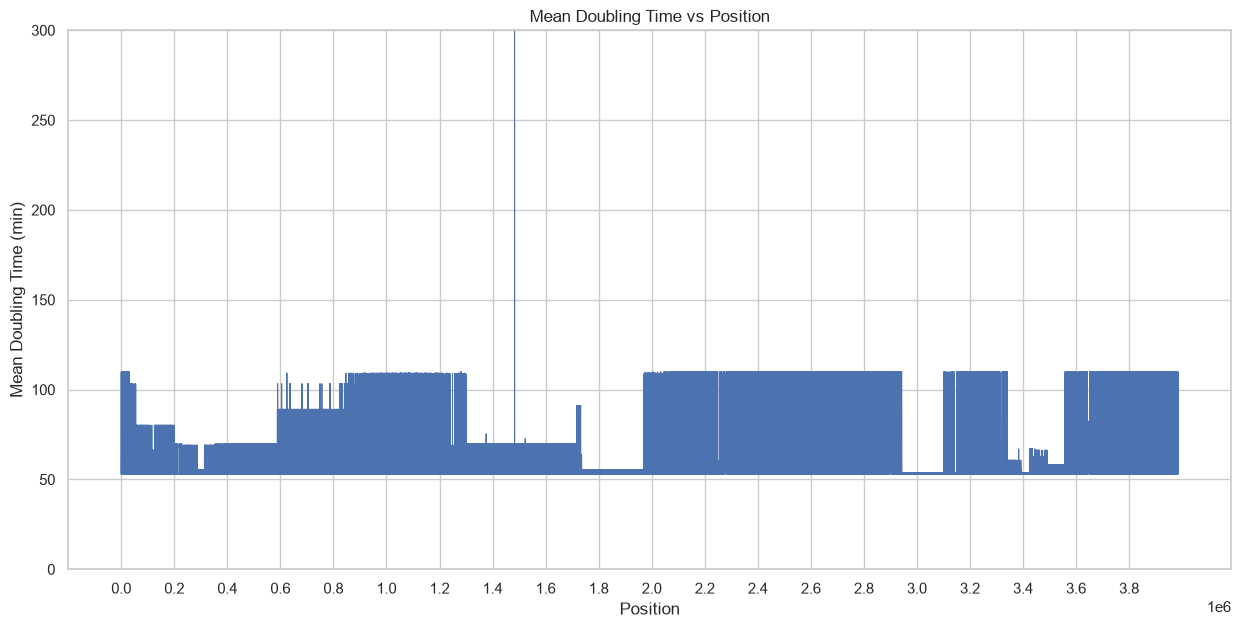

In [131]:
tables_path = os.path.join(RESULTS_DIR, 'recoding', 'tables')

# plot td_mean vs position and td_min vs position on the same plot
plt.figure(figsize=(15, 7))
#sns.scatterplot(x=adata.var['position'], y=adata.var['td_mean'])
sns.lineplot(x=adata.var['position'], y=adata.var['td_min'], size=0.1)
plt.xlabel('Position')
plt.ylabel('Mean Doubling Time (min)')
# legend off
plt.legend([],[], frameon=False)
plt.title('Mean Doubling Time vs Position')
# x axis numbers, every 200 kb
x_ticks = np.arange(adata.var['position'][0], adata.var['position'][-1], 200000)
plt.xticks(x_ticks)
plt.ylim(0, top=300)
plt.savefig(os.path.join(tables_path, 'recoding_landscape.png'), dpi=300)

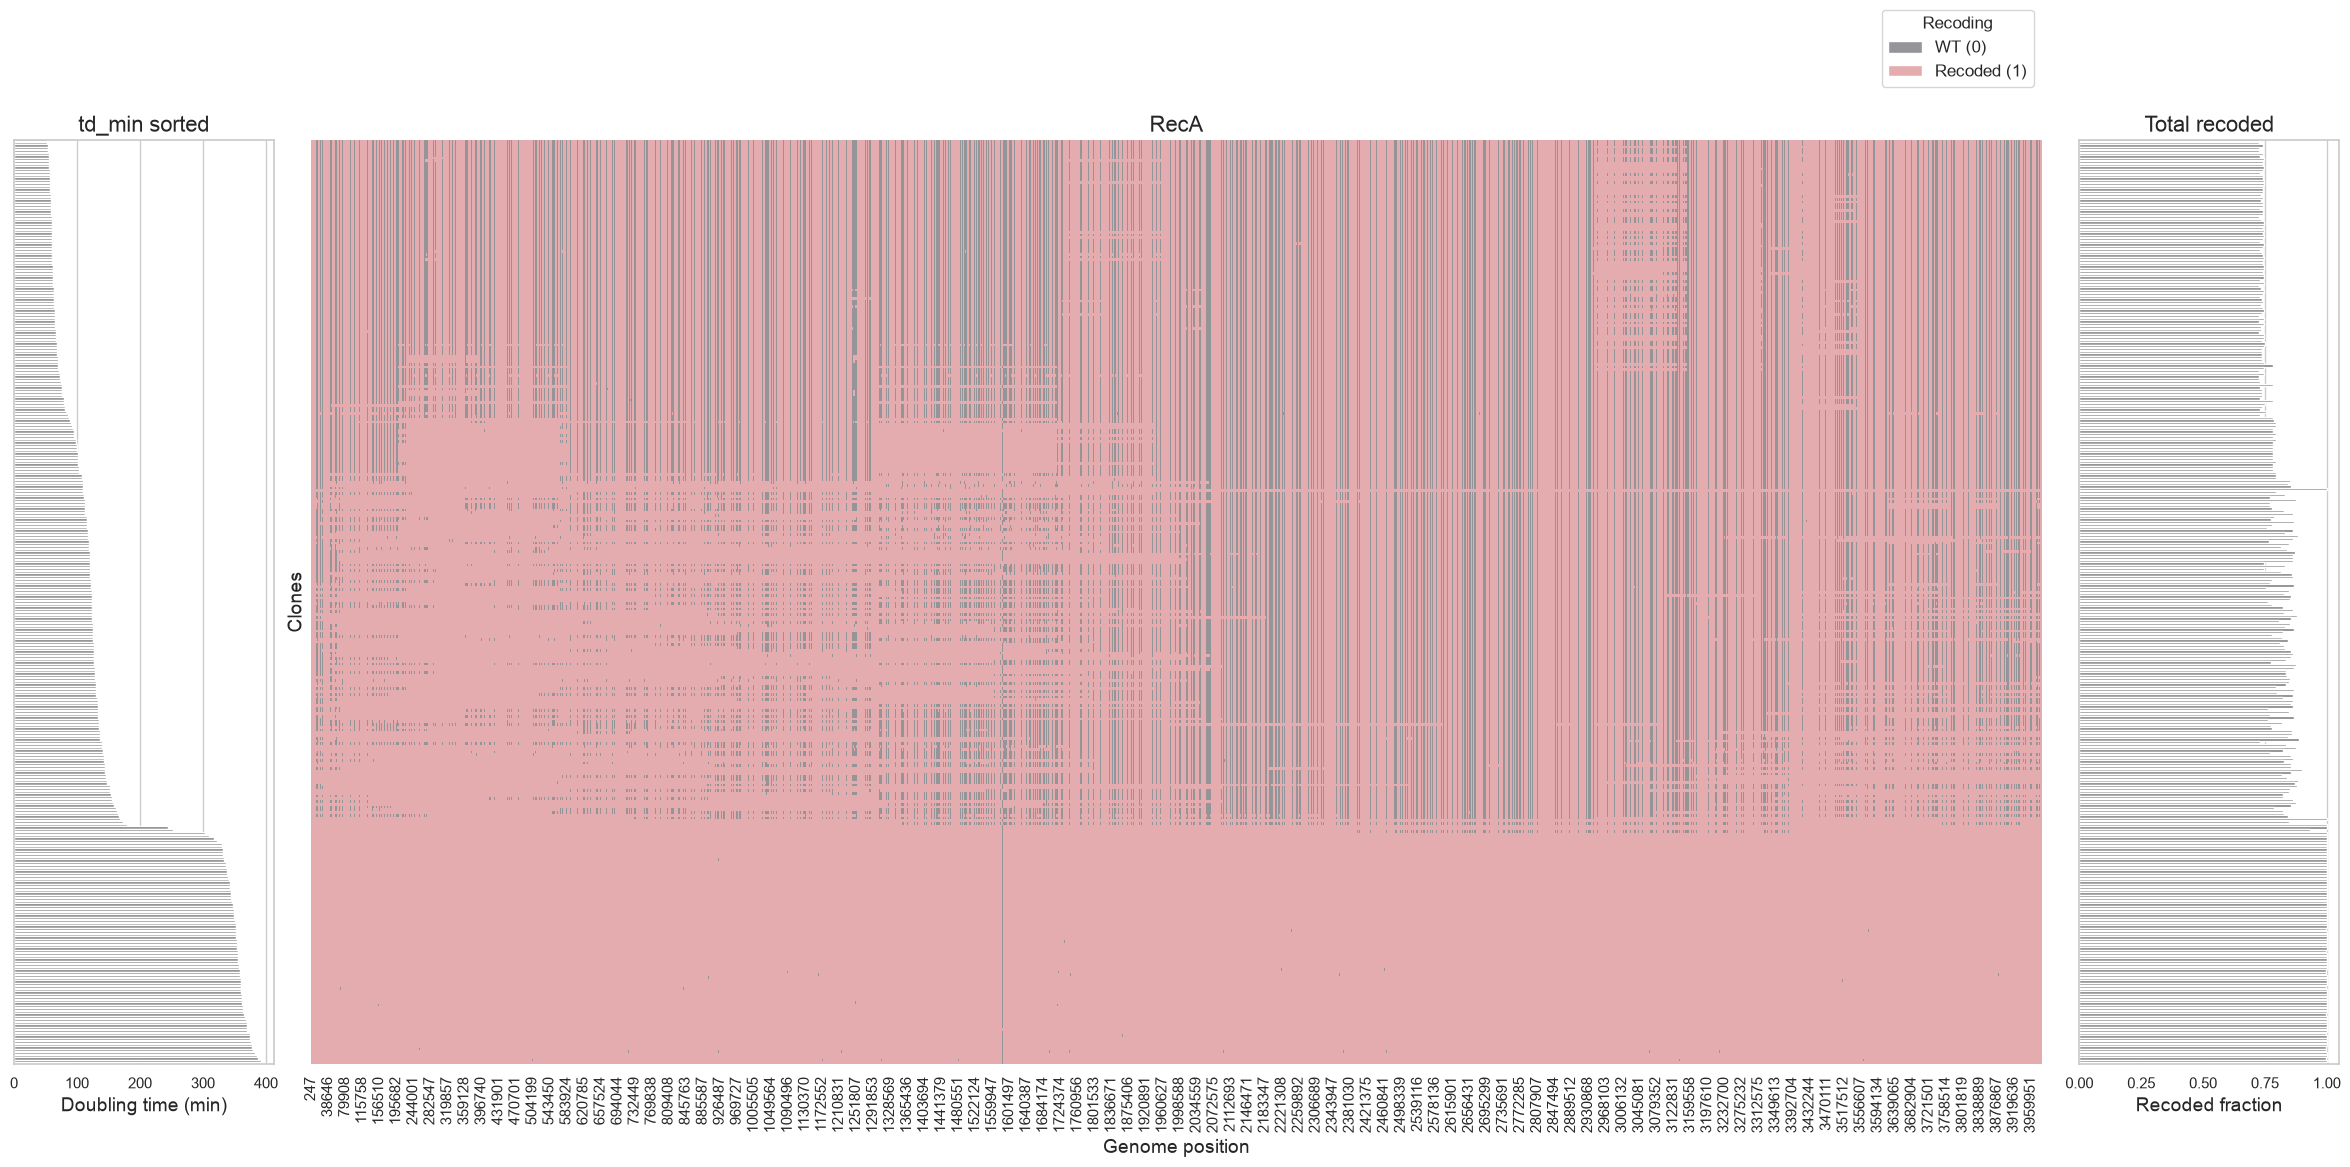

In [132]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

recoding = np.asarray(adata.layers['recoded_binary'])
td_min = np.asarray(adata.obs['td_min'])
total_recoding = np.asarray(adata.obs['recoded_fraction'])

sorted_indices = np.argsort(td_min)
recoding_sorted = recoding[sorted_indices, :]
td_min_sorted = td_min[sorted_indices]
total_recoding_sorted = total_recoding[sorted_indices]

y_positions = np.arange(len(td_min_sorted))
n_clones = len(td_min_sorted)


fig, axes = plt.subplots(
    1, 3,
    figsize=(30, 12),
    gridspec_kw={'width_ratios': [3, 20, 3], 'wspace': 0.05}
)   
ax_td = axes[0]
ax_main = axes[1]
ax_total = axes[2]  
# --- Panel A: td_min horizontal bars ---
#ax_td.barh(y_positions, td_min_sorted, color="#282828")
ax_td.barh(y_positions, td_min_sorted, color='gray')
ax_td.set_ylim(n_clones, 0)
ax_td.set_title("td_min sorted", fontsize=16)
# increase font size of x label
ax_td.set_xlabel("Doubling time (min)", fontsize=14)
ax_td.set_yticks([])
# --- Panel B: binary recoding heatmap ---
binary_cmap = ListedColormap(['#939598', '#e4acaf'])  # 0=WT, 1=Recoded
sns.heatmap(
    recoding_sorted,
    cmap=binary_cmap,
    cbar=False,
    ax=ax_main,
    xticklabels=False,
    yticklabels=False
)
# on x plot codon start position
condon_positions = adata.var['codon_start'].values
# ticks every 1000 codons
ticks_every = 1000
ax_main.set_xticks(np.arange(0, len(condon_positions), ticks_every))
ax_main.set_xticklabels(condon_positions[::ticks_every], rotation=90)

ax_main.set_title("RecA", fontsize=16)
ax_main.set_xlabel("Genome position", fontsize=14)
ax_main.set_ylabel("Clones", fontsize=14)
legend_handles = [
    Patch(facecolor='#939598', label='WT (0)'),
    Patch(facecolor='#e4acaf', label='Recoded (1)')
]
# move legend outside of the plot
ax_main.legend(handles=legend_handles, title="Recoding", loc='upper right', fontsize=12, bbox_to_anchor=(1, 1.15))
# --- Panel C: total_recoding horizontal bars ---
ax_total.barh(y_positions, total_recoding_sorted, color='gray')
ax_total.set_ylim(n_clones, 0)
ax_total.set_title("Total recoded", fontsize=16)
ax_total.set_xlabel("Recoded fraction", fontsize=14)
ax_total.set_yticks([])
plt.savefig(os.path.join(tables_path, 'recoding_landscape_heatmap.png'), dpi=300)

## 6. Derived per-clone metrics and filtering

- `td_min` — doubling time in minutes (AMiGA reports `td` in hours).
- `OD_death` — `death_lin`, renamed for readability.
- `recoded_binary` — per-codon recoding call at `MIXED_TRACE_THRESHOLD`.
- `recoded_total` / `recoded_fraction` — codons recoded per clone.
- `mean_depth` — mean sequencing depth over all codons.

`td` and `death_lin` only exist when AMiGA ran its GP fits; a basic summary carries
`OD_*` alone, so both they and the filters and plots keyed on them are skipped.

In [85]:
if 'td' in adata.obs.columns:
    adata.obs['td_min'] = adata.obs['td'] * 60          # AMiGA reports td in hours
else:
    print("no 'td' column in the summaries — skipping doubling time")
adata.obs = adata.obs.rename(columns={'death_lin': 'OD_death'})

adata.layers['recoded_binary'] = (adata.X > MIXED_TRACE_THRESHOLD).astype(int)
adata.obs['recoded_total']    = adata.layers['recoded_binary'].sum(axis=1)
adata.obs['recoded_fraction'] = adata.obs['recoded_total'] / adata.n_vars
adata.obs['mean_depth']       = adata.layers['depth'].mean(axis=1)

# Growth metrics this run actually has; everything downstream follows this list.
GROWTH_METRICS = [m for m in ['td_min', 'OD_Max', 'OD_death'] if m in adata.obs.columns]
print(f'growth metrics available: {GROWTH_METRICS}')

n0 = adata.n_obs
adata = adata[adata.obs['mean_depth'] >= DEPTH_THRESHOLD].copy()
print(f'mean depth >= {DEPTH_THRESHOLD}: {adata.n_obs} / {n0}')

if 'td_min' in adata.obs.columns:
    n0 = adata.n_obs
    adata = adata[adata.obs['td_min'] <= TD_THRESHOLD_MIN].copy()
    print(f'td <= {TD_THRESHOLD_MIN} min:    {adata.n_obs} / {n0}')

if OD_THRESHOLD is not None:
    n0 = adata.n_obs
    adata = adata[adata.obs['OD_Max'] > OD_THRESHOLD].copy()
    print(f'OD_Max > {OD_THRESHOLD}:        {adata.n_obs} / {n0}')

adata.obs[GROWTH_METRICS + ['recoded_fraction', 'mean_depth']].describe()

growth metrics available: ['td_min', 'OD_Max', 'OD_death']
mean depth >= 10: 345 / 384
td <= 300 min:    254 / 345


,td_min,OD_Max,OD_death,recoded_fraction,mean_depth
count,254.000000,254.000000,254.000000,254.000000,254.000000
mean,101.908817,1.286882,0.269264,0.793697,54.585892
std,35.908988,0.202500,0.233703,0.057440,44.769019
min,52.952865,0.506000,0.000000,0.727630,10.386092
25%,64.399057,1.172250,0.096482,0.743864,34.715399
50%,109.001671,1.310500,0.140319,0.783098,45.952967
75%,127.143860,1.451500,0.425006,0.843186,58.882061
max,253.084656,1.767000,0.842958,0.999498,493.564268


## 8. Summarise growth per codon into `var`

For each codon, the distribution of a growth metric across the clones recoded at
that codon. Codons that no surviving clone recodes come out as NaN (rather than
raising), and `n_recoded` records how many clones each statistic rests on.

In [86]:
STATS = ['min', 'max', 'mean', 'median', 'std']

mask = adata.layers['recoded_binary'] > 0                 # (n_obs, n_vars)
adata.var['n_recoded'] = mask.sum(axis=0)

with warnings.catch_warnings():
    warnings.simplefilter('ignore', RuntimeWarning)       # all-NaN columns
    for metric in GROWTH_METRICS:
        values = adata.obs[metric].to_numpy(dtype=float)[:, None]
        masked = np.where(mask, values, np.nan)
        for stat in STATS:
            adata.var[f'{metric}_{stat}'] = getattr(np, f'nan{stat}')(masked, axis=0)

print(f'codons with no recoded clone: {(adata.var["n_recoded"] == 0).sum()} / {adata.n_vars}')
adata.var.head()

codons with no recoded clone: 36 / 101652


,position,n_recoded,td_min_min,td_min_max,td_min_mean,td_min_median,td_min_std,OD_Max_min,OD_Max_max,OD_Max_mean,OD_Max_median,OD_Max_std,OD_death_min,OD_death_max,OD_death_mean,OD_death_median,OD_death_std
codon_247,247,254,52.952865,253.084656,101.908817,109.001671,35.838231,0.506,1.767,1.286882,1.3105,0.202101,0.000000,0.842958,0.269264,0.140319,0.233243
codon_364,364,48,109.885673,253.084656,141.830526,135.819774,27.885601,0.506,1.595,1.060438,1.0830,0.210457,0.042344,0.693342,0.184028,0.116741,0.155118
codon_370,370,254,52.952865,253.084656,101.908817,109.001671,35.838231,0.506,1.767,1.286882,1.3105,0.202101,0.000000,0.842958,0.269264,0.140319,0.233243
codon_376,376,254,52.952865,253.084656,101.908817,109.001671,35.838231,0.506,1.767,1.286882,1.3105,0.202101,0.000000,0.842958,0.269264,0.140319,0.233243
codon_448,448,44,82.344163,253.084656,143.742823,138.497898,28.931819,0.506,1.595,1.046136,1.0295,0.215002,0.000558,0.693342,0.167982,0.108963,0.155476


## 9. QC plots

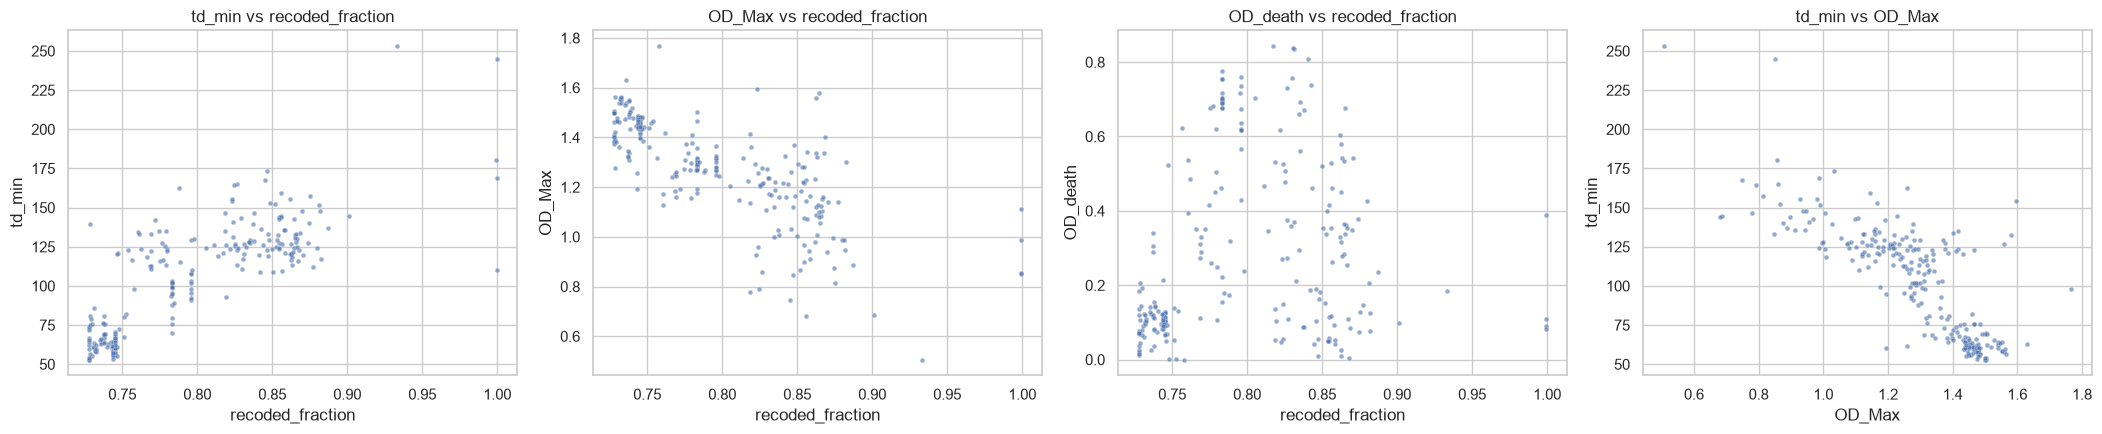

In [87]:
pairs = [('recoded_fraction', m) for m in GROWTH_METRICS]
if {'OD_Max', 'td_min'} <= set(GROWTH_METRICS):
    pairs.append(('OD_Max', 'td_min'))

fig, axes = plt.subplots(1, len(pairs), figsize=(5.3 * len(pairs), 4.5), squeeze=False)
for ax, (x, y) in zip(axes[0], pairs):
    sns.scatterplot(x=adata.obs[x], y=adata.obs[y], s=12, alpha=.6, ax=ax)
    ax.set(xlabel=x, ylabel=y, title=f'{y} vs {x}')
fig.tight_layout()
plt.show()

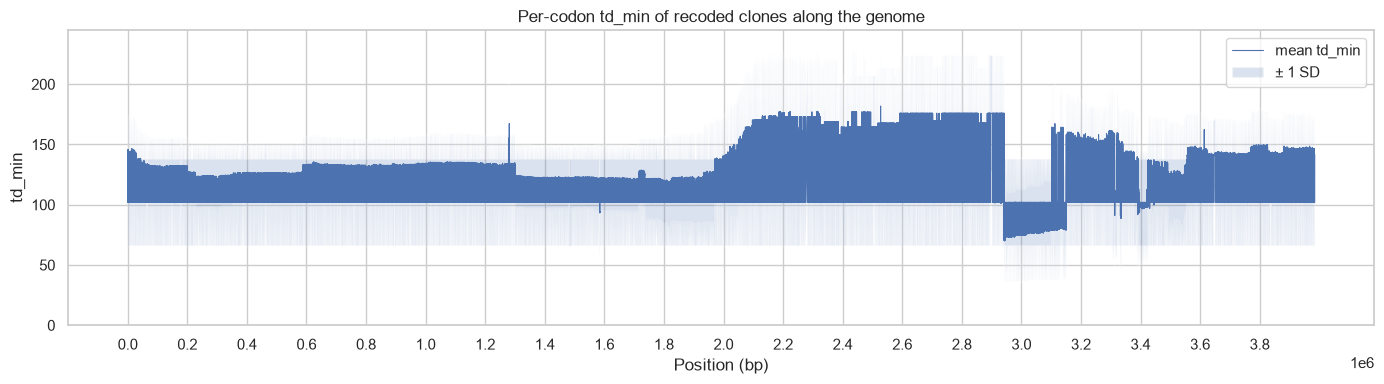

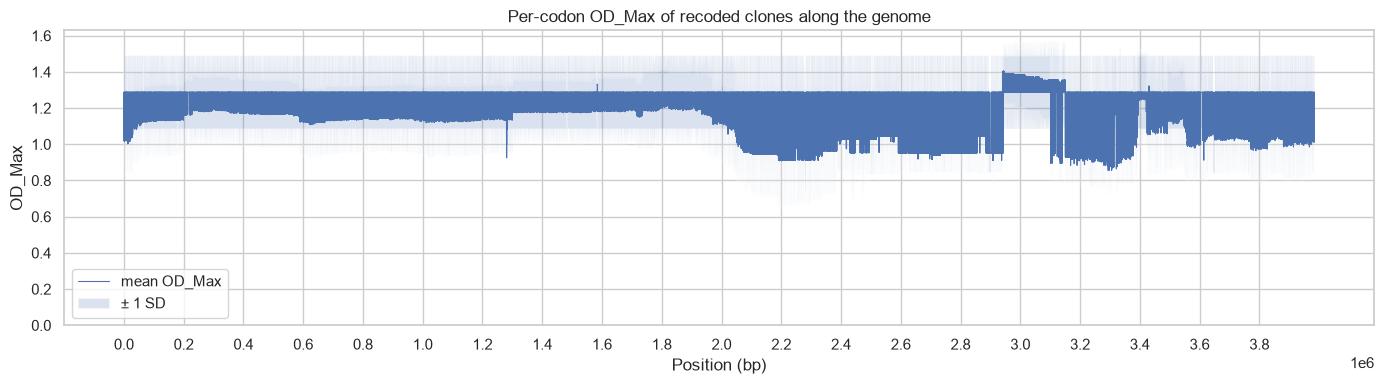

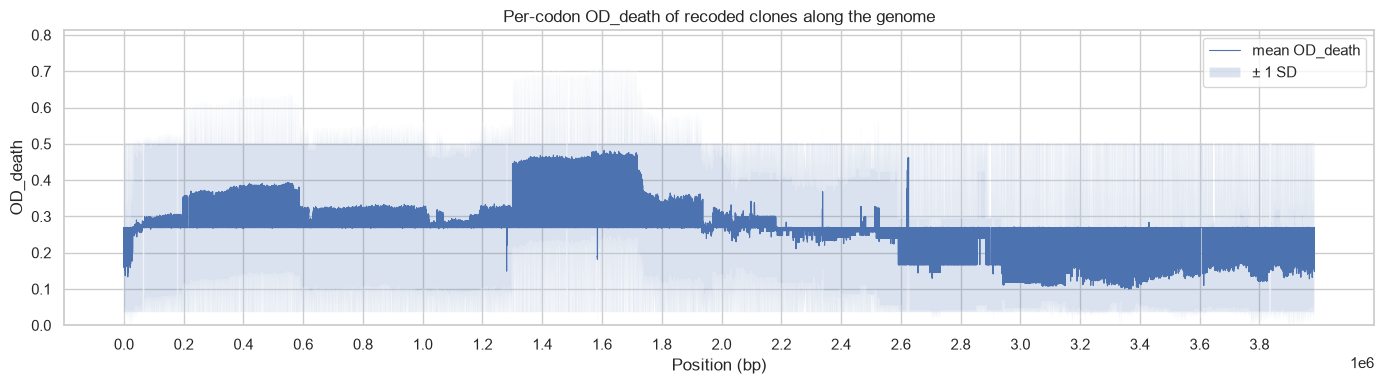

In [88]:
# Per-codon growth along the genome: mean over the clones recoded at each codon.
pos = adata.var['position'].to_numpy()

for metric in GROWTH_METRICS:
    mean = adata.var[f'{metric}_mean'].to_numpy()
    std  = adata.var[f'{metric}_std'].to_numpy()

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(pos, mean, lw=.8, label=f'mean {metric}')
    ax.fill_between(pos, mean - std, mean + std, alpha=.2, label='± 1 SD')
    ax.set(xlabel='Position (bp)', ylabel=metric,
           title=f'Per-codon {metric} of recoded clones along the genome')
    ax.set_xticks(np.arange(pos.min(), pos.max(), 200_000))
    ax.set_ylim(bottom=0)
    ax.legend()
    fig.tight_layout()
    plt.show()

## 10. Landscape figures

The two figures from `recA_data.ipynb`, reproduced as that notebook draws them and
saved to `FIG_DIR` at 300 dpi:

1. **Per-codon landscape** — `var['td_min_min']`, the shortest doubling time among
   the clones recoded at each codon (recA's `var['td_min']`), against position.
2. **Clone × codon heatmap** — clones sorted by doubling time, flanked by `td_min`
   on the left and the total recoded fraction on the right.

Both need `td_min`, so both are skipped when AMiGA ran without its GP fits.

In [89]:
os.makedirs(FIG_DIR, exist_ok=True)
HAS_TD = 'td_min' in GROWTH_METRICS
if not HAS_TD:
    print("no 'td_min' — skipping the landscape figures (rerun AMiGA with the GP fits)")

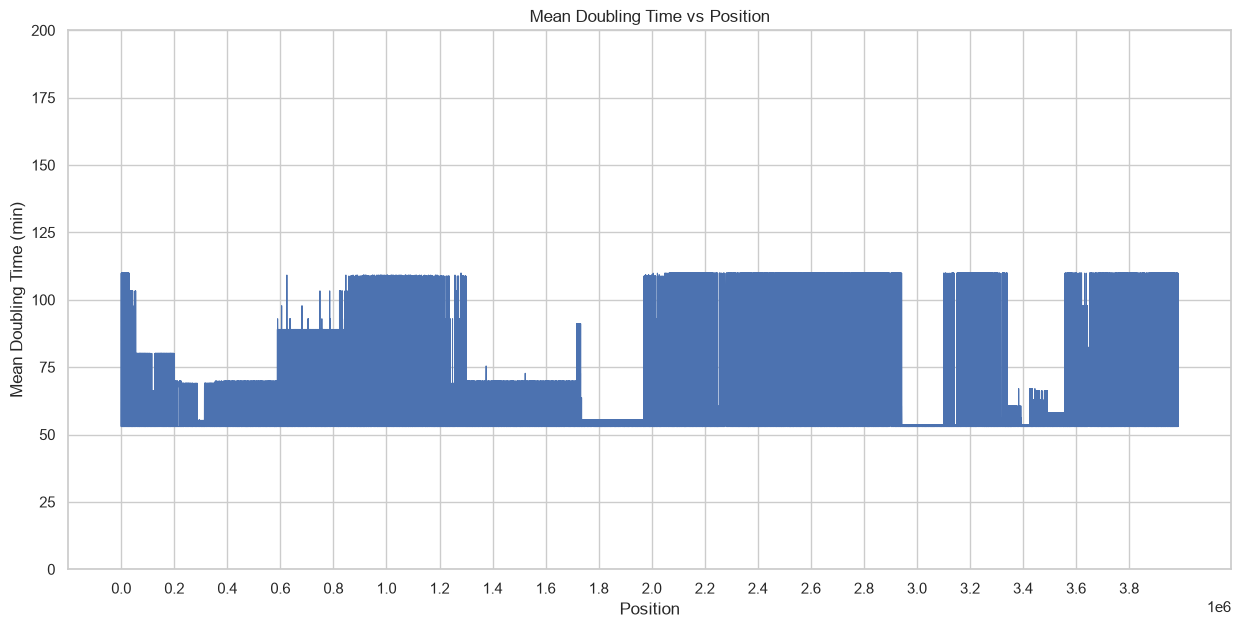

In [92]:
# recA_data.ipynb: minimum doubling time per codon vs position.
# var['td_min_min'] here == var['td_min'] there (min of td_min over recoded clones).
if HAS_TD:
    plt.figure(figsize=(15, 7))
    sns.lineplot(x=adata.var['position'], y=adata.var['td_min_min'], size=0.1)
    plt.xlabel('Position')
    plt.ylabel('Mean Doubling Time (min)')
    plt.legend([], [], frameon=False)
    plt.title('Mean Doubling Time vs Position')
    x_ticks = np.arange(adata.var['position'].iloc[0], adata.var['position'].iloc[-1], 200000)
    plt.xticks(x_ticks)
    plt.ylim(0, top=LANDSCAPE_YLIM[1])
    plt.savefig(os.path.join(FIG_DIR, 'recoding_landscape.png'), dpi=300)
    plt.show()

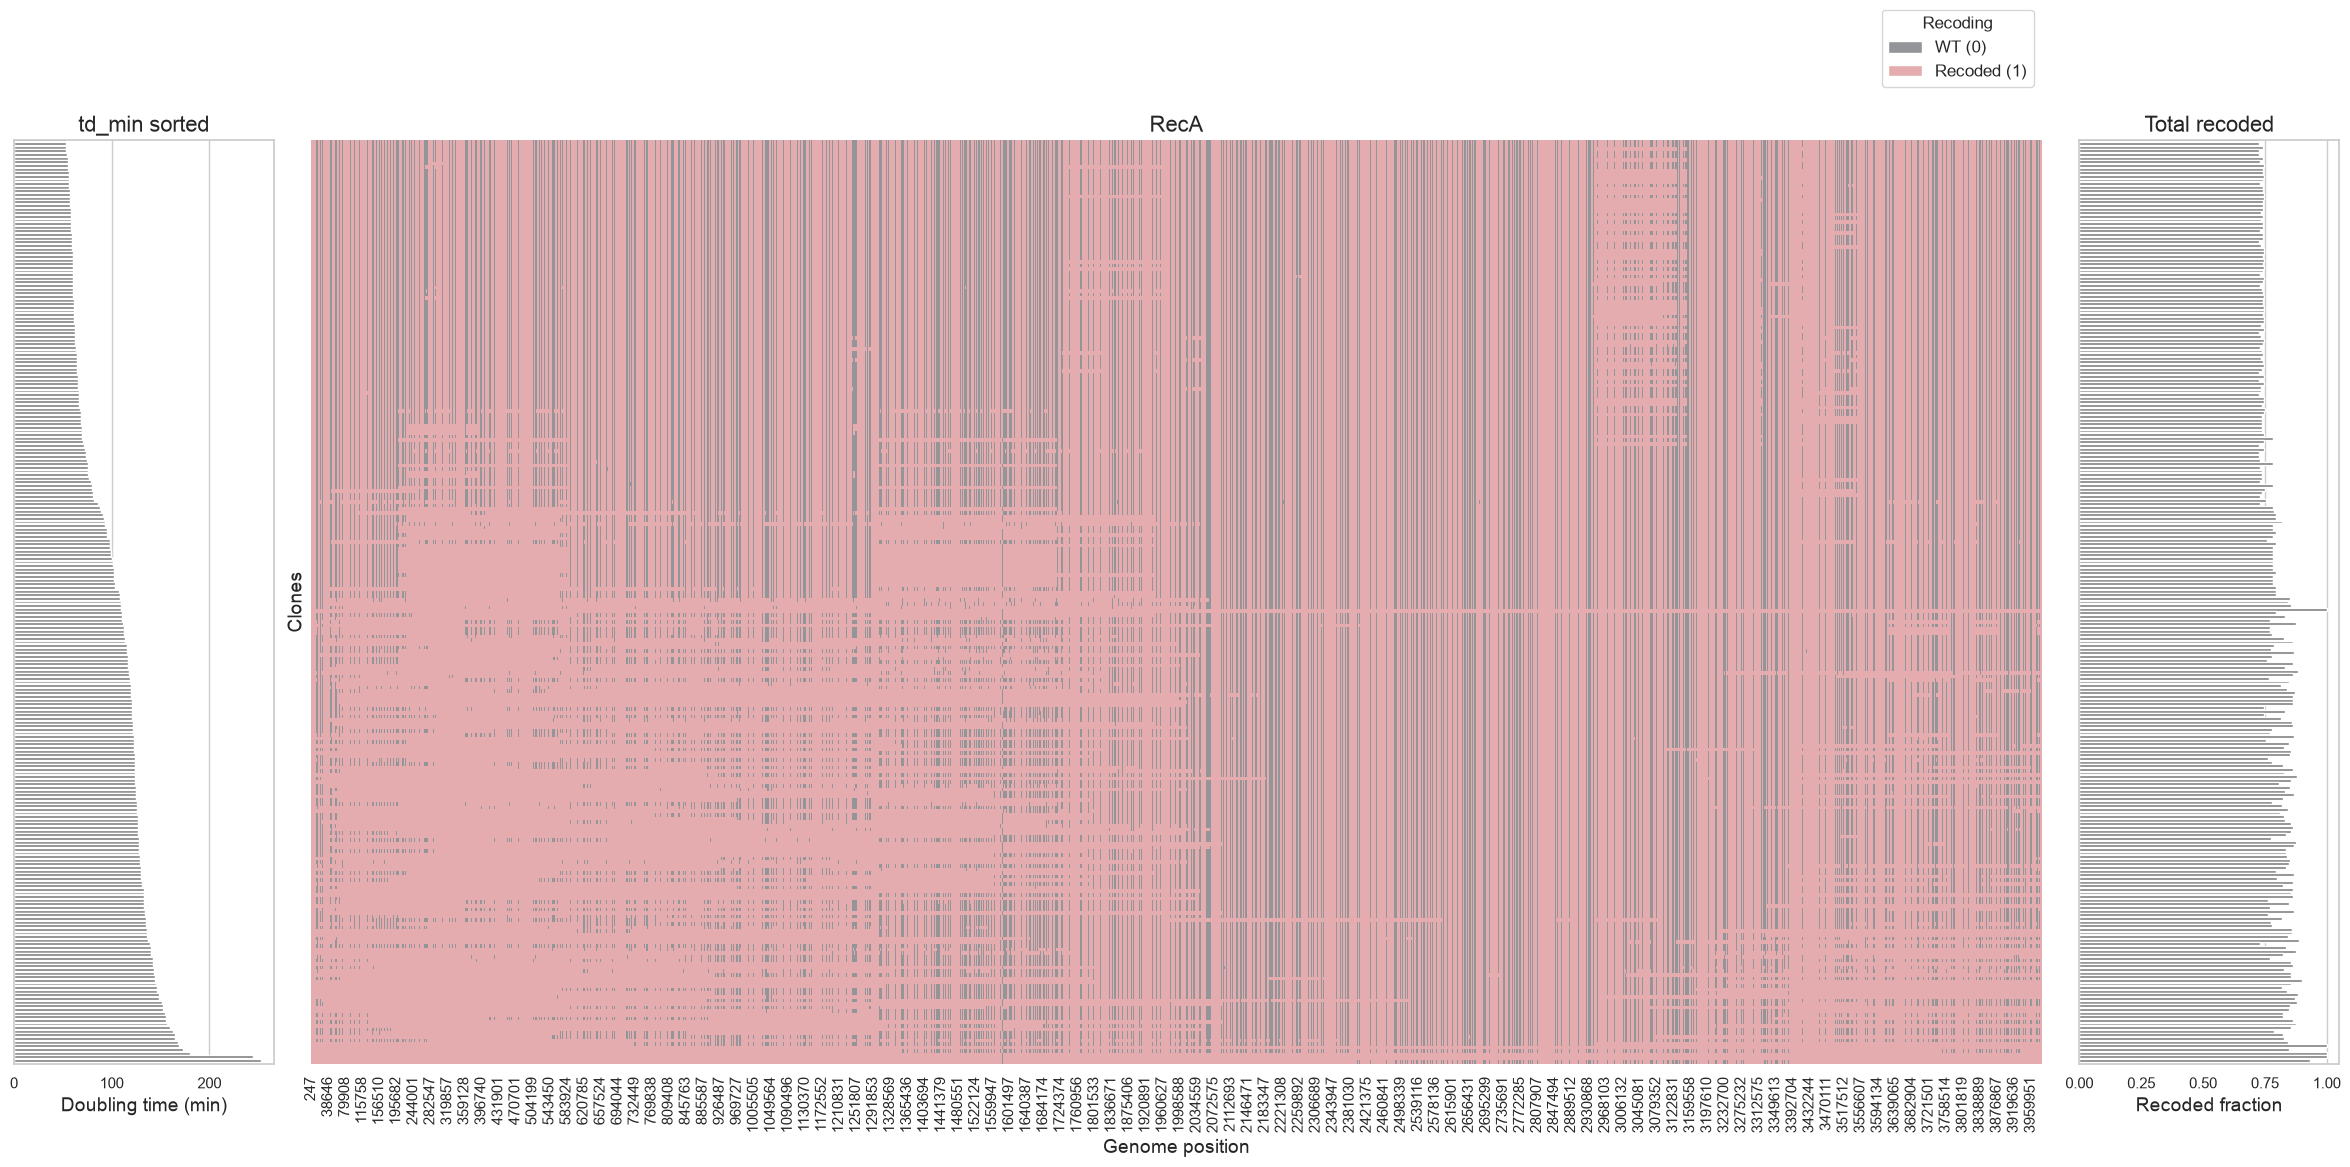

In [91]:
# recA_data.ipynb: clones sorted by td_min, binary recoding heatmap between the
# doubling-time bars and the total-recoded bars.
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

if HAS_TD:
    recoding = np.asarray(adata.layers['recoded_binary'])
    td_min = np.asarray(adata.obs['td_min'])
    total_recoding = np.asarray(adata.obs['recoded_fraction'])

    sorted_indices = np.argsort(td_min)
    recoding_sorted = recoding[sorted_indices, :]
    td_min_sorted = td_min[sorted_indices]
    total_recoding_sorted = total_recoding[sorted_indices]

    y_positions = np.arange(len(td_min_sorted))
    n_clones = len(td_min_sorted)

    fig, axes = plt.subplots(
        1, 3,
        figsize=(30, 12),
        gridspec_kw={'width_ratios': [3, 20, 3], 'wspace': 0.05}
    )
    ax_td, ax_main, ax_total = axes

    # --- Panel A: td_min horizontal bars ---
    ax_td.barh(y_positions, td_min_sorted, color='gray')
    ax_td.set_ylim(n_clones, 0)
    ax_td.set_title('td_min sorted', fontsize=16)
    ax_td.set_xlabel('Doubling time (min)', fontsize=14)
    ax_td.set_yticks([])

    # --- Panel B: binary recoding heatmap ---
    binary_cmap = ListedColormap(['#939598', '#e4acaf'])  # 0=WT, 1=Recoded
    sns.heatmap(
        recoding_sorted,
        cmap=binary_cmap,
        cbar=False,
        ax=ax_main,
        xticklabels=False,
        yticklabels=False
    )
    codon_positions = adata.var['position'].values
    ax_main.set_xticks(np.arange(0, len(codon_positions), TICKS_EVERY))
    ax_main.set_xticklabels(codon_positions[::TICKS_EVERY], rotation=90)

    ax_main.set_title(HEATMAP_LABEL, fontsize=16)
    ax_main.set_xlabel('Genome position', fontsize=14)
    ax_main.set_ylabel('Clones', fontsize=14)
    legend_handles = [
        Patch(facecolor='#939598', label='WT (0)'),
        Patch(facecolor='#e4acaf', label='Recoded (1)')
    ]
    ax_main.legend(handles=legend_handles, title='Recoding', loc='upper right',
                   fontsize=12, bbox_to_anchor=(1, 1.15))

    # --- Panel C: total_recoding horizontal bars ---
    ax_total.barh(y_positions, total_recoding_sorted, color='gray')
    ax_total.set_ylim(n_clones, 0)
    ax_total.set_title('Total recoded', fontsize=16)
    ax_total.set_xlabel('Recoded fraction', fontsize=14)
    ax_total.set_yticks([])

    plt.savefig(os.path.join(FIG_DIR, 'recoding_landscape_heatmap.png'), dpi=300)
    plt.show()

## 11. Write out

`recoding_growth.h5ad` sits next to the pipeline's `recoding_landscape.h5ad`, plus
flat `obs` / `var` tables for anything that would rather read CSV.

In [56]:
adata.write_h5ad(OUT_H5AD)
adata.obs.to_csv(os.path.join(ANNDATA_DIR, 'recoding_growth_obs.csv'))
adata.var.to_csv(os.path.join(ANNDATA_DIR, 'recoding_growth_var.csv'))
print(f'wrote {OUT_H5AD}  shape={adata.shape}')
adata

wrote /Users/cristian.soitu/Data/260901_VH02427_87_AAJCWWFM5/results/recoding/anndata/recoding_growth.h5ad  shape=(345, 101652)


AnnData object with n_obs × n_vars = 345 × 101652
    obs: 'BAM_name', 'well_ID', 'well_nr', 'sample_ID', 'seq_plate_ID', 'clone_nr', 'sample_nr', 'plate_name', 'Group', 'Control', 'Flag', 'Subset', 'OD_Baseline', 'OD_Min', 'OD_Max', 'OD_Emp_AUC', 'Fold_Change', 'recoded_total', 'recoded_fraction', 'mean_depth'
    var: 'position', 'n_recoded', 'OD_Max_min', 'OD_Max_max', 'OD_Max_mean', 'OD_Max_median', 'OD_Max_std'
    layers: 'depth', 'recoded_count', None (.X), 'recoded_binary'